In [3]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
dsd = load_dataset("benjis/bigvul")

Load_dataset trả về một DatasetDict, nó chứa nhiều tập con (split) train, validation, test.

In [6]:
sns.set_theme(style="whitegrid")
df = pd.concat(
    [dsd[split].to_pandas() for split in dsd],
    ignore_index=True
)
df.head(10)

,CVE ID,CVE Page,CWE ID,codeLink,commit_id,commit_message,func_after,func_before,lang,project,vul
0,CVE-2017-7586,https://www.cvedetails.com/cve/CVE-2017-7586/,CWE-119,https://github.com/erikd/libsndfile/commit/708...,708e996c87c5fae77b104ccfeb8f6db784c32074,src/ : Move to a variable length header buffer...,"psf_get_date_str (char *str, int maxlen)\n{\tt...","psf_get_date_str (char *str, int maxlen)\n{\tt...",C,libsndfile,0
1,CVE-2018-18352,https://www.cvedetails.com/cve/CVE-2018-18352/,CWE-732,https://github.com/chromium/chromium/commit/a9...,a9cbaa7a40e2b2723cfc2f266c42f4980038a949,"Simplify ""WouldTaintOrigin"" concept in media/b...",void MultibufferDataSource::CreateResourceLoad...,void MultibufferDataSource::CreateResourceLoad...,C,Chrome,0
2,CVE-2010-1166,https://www.cvedetails.com/cve/CVE-2010-1166/,CWE-189,https://cgit.freedesktop.org/xorg/xserver/comm...,d2f813f7db157fc83abc4b3726821c36ee7e40b1,NaN,"fbStore_a2r2g2b2 (FbBits *bits, const CARD32 *...","fbStore_a2r2g2b2 (FbBits *bits, const CARD32 *...",C,xserver,0
3,NaN,NaN,NaN,https://github.com/chromium/chromium/commit/61...,610f904d8215075c4681be4eb413f4348860bf9f,Retrieve per host storage usage from QuotaMana...,void UsageTracker::DidGetClientGlobalUsage(Sto...,void UsageTracker::DidGetClientGlobalUsage(Sto...,C,Chrome,0
4,NaN,NaN,NaN,https://github.com/chromium/chromium/commit/95...,957973753ec4159003ff7930d946b7e89c7e09f3,Make NotifyHeadersComplete the last call in th...,void BlobURLRequestJob::DidRead(int result) {\...,void BlobURLRequestJob::DidRead(int result) {\...,C,Chrome,0
5,CVE-2017-11462,https://www.cvedetails.com/cve/CVE-2017-11462/,CWE-415,https://github.com/krb5/krb5/commit/56f7b1bc95...,56f7b1bc95a2a3eeb420e069e7655fb181ade5cf,Preserve GSS context on init/accept failure\n\...,"gss_get_mic (minor_status,\n\t context_han...","gss_get_mic (minor_status,\n\t context_han...",C,krb5,1
6,CVE-2013-0910,https://www.cvedetails.com/cve/CVE-2013-0910/,CWE-287,https://github.com/chromium/chromium/commit/ac...,ac8bd041b81e46e4e4fcd5021aaa5499703952e6,Follow-on fixes and naming changes for https:/...,void PluginServiceImpl::RegisterFilePathWatche...,void PluginServiceImpl::RegisterFilePathWatche...,C,Chrome,0
7,CVE-2015-5195,https://www.cvedetails.com/cve/CVE-2015-5195/,CWE-20,https://github.com/ntp-project/ntp/commit/52e9...,52e977d79a0c4ace997e5c74af429844da2f27be,[Bug 1773] openssl not detected during ./confi...,"record_loop_stats(\n\tdouble\toffset,\t\t/* of...","record_loop_stats(\n\tdouble\toffset,\t\t/* of...",C,ntp,0
8,CVE-2017-18222,https://www.cvedetails.com/cve/CVE-2017-18222/,CWE-119,https://github.com/torvalds/linux/commit/412b6...,412b65d15a7f8a93794653968308fc100f2aa87c,net: hns: fix ethtool_get_strings overflow in ...,static void hns_xgmac_exc_irq_en(struct mac_dr...,static void hns_xgmac_exc_irq_en(struct mac_dr...,C,linux,0
9,CVE-2018-6077,https://www.cvedetails.com/cve/CVE-2018-6077/,CWE-200,https://github.com/chromium/chromium/commit/6e...,6ed26f014f76f10e76e80636027a2db9dcbe1664,[PE] Distinguish between tainting due to canva...,void BaseRenderingContext2D::clip(Path2D* dom_...,void BaseRenderingContext2D::clip(Path2D* dom_...,C,Chrome,0


In [12]:
print("Số dòng: ", df.shape[0])
print("Số cột: ", df.shape[1])

Số dòng:  217007
Số cột:  11


vul=0 (an toàn)    : 206,112  (94.98%)
vul=1 (có lỗ hổng) : 10,895  (5.02%)
Tỉ số              : 18.9 : 1


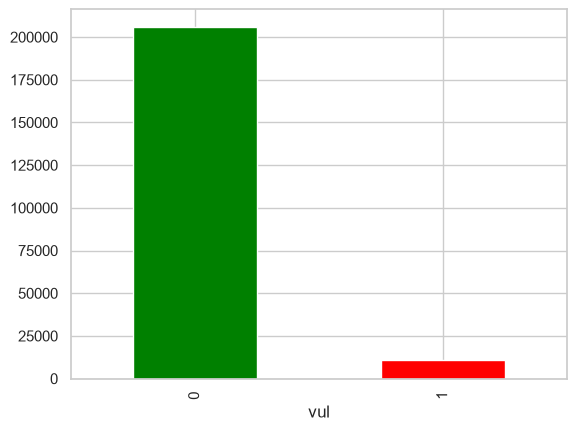

In [25]:
df["vul"].value_counts().plot(kind="bar", color=["green", "red"])
vc = df["vul"].value_counts().sort_index()
n_safe, n_vul = int(vc[0]), int(vc[1])
print(f"vul=0 (an toàn)    : {n_safe:,}  ({n_safe/len(df):.2%})")
print(f"vul=1 (có lỗ hổng) : {n_vul:,}  ({n_vul/len(df):.2%})")
print(f"Tỉ số              : {n_safe/n_vul:.1f} : 1")

In [24]:
#Lúc đầu thì bao gồm C, CPP, C++, chuyển về còn C, C++
LANG_MAP = {"C": "C", "CPP": "C++", "C++": "C++"}
df["lang"] = df["lang"].map(LANG_MAP)
print(f"Giá trị lạ sau khi map (NaN): {df['lang'].isna().sum()}")
df["lang"].value_counts()

Giá trị lạ sau khi map (NaN): 0


lang
C      213919
C++      3088
Name: count, dtype: int64

   CWE-119    2,139  (19.6%)
   CWE-20     1,136  (10.4%)
   CWE-399      742  ( 6.8%)
   CWE-125      630  ( 5.8%)
   CWE-200      508  ( 4.7%)
   CWE-264      493  ( 4.5%)
   CWE-189      341  ( 3.1%)
   CWE-416      323  ( 3.0%)
   CWE-190      311  ( 2.9%)
   CWE-362      266  ( 2.4%)


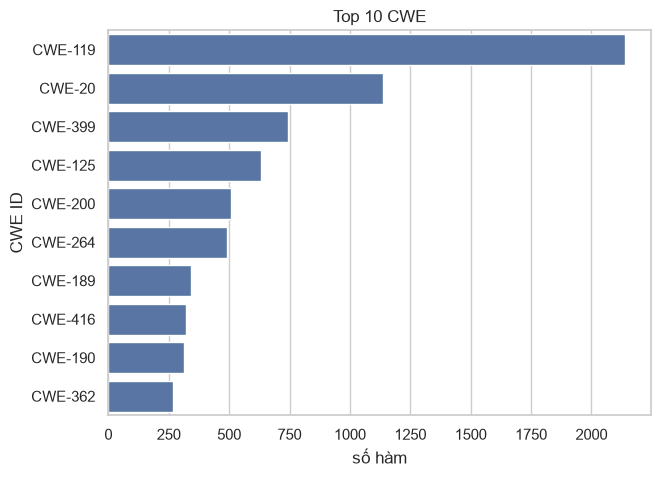

In [27]:
vul_only = df[df["vul"] == 1]
top_cwe = vul_only["CWE ID"].value_counts().head(10)
for cwe, n in top_cwe.items():
    print(f"   {str(cwe):10s} {n:>5,}  ({n/len(vul_only):5.1%})")

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=top_cwe.values, y=top_cwe.index, ax=ax)
ax.set_xlabel("số hàm")
ax.set_title("Top 10 CWE")
plt.show()

Độ dài func_before (ký tự):
count    217,007
mean         899
std        2,473
min           14
25%          193
50%          393
75%          868
max      240,969
Name: func_before, dtype: str


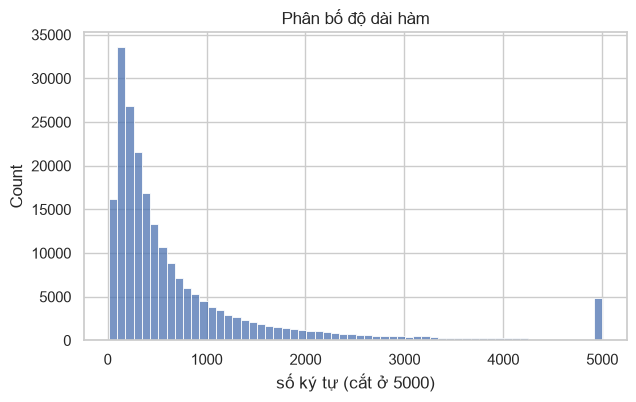


Hàm dài hơn 5000 ký tự: 4,716 (2.2%)


In [28]:
lens = df["func_before"].str.len()

print("Độ dài func_before (ký tự):")
print(lens.describe().apply(lambda x: f"{x:,.0f}"))

fig, ax = plt.subplots(figsize=(7, 4))
# clip để vài hàm cực dài không kéo giãn trục x làm mất hình dạng phần thân
sns.histplot(lens.clip(upper=5000), bins=60, ax=ax)
ax.set_xlabel("số ký tự (cắt ở 5000)")
ax.set_title("Phân bố độ dài hàm")
plt.show()

print(f"\nHàm dài hơn 5000 ký tự: {(lens > 5000).sum():,} ({(lens > 5000).mean():.1%})")

In [29]:
n_rows = len(df)
n_commits = df["commit_id"].nunique()
per_commit = df.groupby("commit_id").size()

print("=" * 50)
print(f"Tổng số dòng          : {n_rows:,}")
print(f"Số commit riêng biệt  : {n_commits:,}")
print("=" * 50)
print("Hàm / commit:")
print(f"   trung vị   : {per_commit.median():>8,.0f}")
print(f"   trung bình : {per_commit.mean():>8,.1f}")
print(f"   lớn nhất   : {per_commit.max():>8,}")
print(f"   p95        : {per_commit.quantile(0.95):>8,.0f}")


Tổng số dòng          : 217,007
Số commit riêng biệt  : 4,019
Hàm / commit:
   trung vị   :       24
   trung bình :     54.0
   lớn nhất   :    1,692
   p95        :      189


### Phân tích
Big-Vul không lấy hàm lẻ. Nó lấy theo commit vá lỗi, và mỗi commit nhả ra hàng chục hàm. Nếu commit X có hàm ở cả hai bên dù không hàm nào trùng y hết, train và test vẫn chứa cùng một bản vá, cùng một file, cùng một tác giả, cùng style.

In [30]:
import hashlib
import re

tr = dsd["train"].to_pandas()
te = dsd["test"].to_pandas()

print(f"Split chính thức:  train {len(tr):,}   test {len(te):,}")


Split chính thức:  train 150,908   test 33,050


In [31]:
s_tr = set(tr["func_before"])
s_te = set(te["func_before"])
dup = s_tr & s_te

print(f"Hàm riêng biệt : train {len(s_tr):,}   test {len(s_te):,}")
print(f"Trùng y hệt    : {len(dup):,}  ({len(dup)/len(s_te):.1%} của test)")


Hàm riêng biệt : train 150,908   test 31,710
Trùng y hệt    : 24,002  (75.7% của test)


In [36]:
def normalize_code(code):
    return re.sub(r"\s+", " ", str(code)).strip()


def code_fingerprint(code):
    return hashlib.sha256(normalize_code(code).encode("utf-8")).hexdigest()


demo = 'void  f( int   x )\n{\n\treturn x;\n}'
print(f"Gốc       : {demo!r}")
print(f"Chuẩn hóa : {normalize_code(demo)!r}")
print(f"Hash      : {code_fingerprint(demo)[:24]}...")


Gốc       : 'void  f( int   x )\n{\n\treturn x;\n}'
Chuẩn hóa : 'void f( int x ) { return x; }'
Hash      : 4d9e07d025f7ae05ea2c1873...


In [38]:
f_tr = {code_fingerprint(c) for c in tr["func_before"]}
f_te = {code_fingerprint(c) for c in te["func_before"]}
near = f_tr & f_te

print(f"Trùng sau chuẩn hóa : {len(near):,}  ({len(near)/len(f_te):.1%} của test)")
print(f"Phát hiện thêm so với trước chuẩn hoá  : {len(near) - len(dup):,}")


Trùng sau chuẩn hóa : 24,095  (76.1% của test)
Phát hiện thêm so với trước chuẩn hoá  : 93


In [39]:
for col in ["commit_id", "project", "CVE ID"]:
    a = set(tr[col].dropna())
    b = set(te[col].dropna())
    ov = a & b
    print(f"{col:11s}: {len(ov):>6,} / {len(b):>6,} nhóm của test cũng có ở train  ({len(ov)/len(b):6.1%})")    

commit_id  :  3,208 /  3,215 nhóm của test cũng có ở train  ( 99.8%)
project    :    289 /    289 nhóm của test cũng có ở train  (100.0%)
CVE ID     :  2,865 /  2,867 nhóm của test cũng có ở train  ( 99.9%)


#### Vấn đề
```c
int add(int a, int b) { return a + b; }
int sum(int x, int y) { return x + y; }
```
Nếu gặp hash thì nó sẽ khác nhau về giá trị, tuy nhiên về ý nghĩa thì nó vẫn tương tự nhau. 

In [2]:
C_KEYWORDS = {
    # C
    "auto", "break", "case", "char", "const", "continue", "default", "do",
    "double", "else", "enum", "extern", "float", "for", "goto", "if", "inline",
    "int", "long", "register", "restrict", "return", "short", "signed",
    "sizeof", "static", "struct", "switch", "typedef", "union", "unsigned",
    "void", "volatile", "while", "bool", "true", "false", "NULL",
    # C++
    "class", "public", "private", "protected", "virtual", "new", "delete",
    "namespace", "template", "typename", "this", "using", "try", "catch",
    "throw", "nullptr", "operator", "static_cast", "const_cast",
    "reinterpret_cast", "dynamic_cast", "friend", "explicit", "mutable",
}


RE_COMMENT = re.compile(r"//[^\n]*|/\*.*?\*/", re.S)
RE_STRING = re.compile(r'"(?:[^"\\]|\\.)*"')
RE_CHAR = re.compile(r"'(?:[^'\\]|\\.)*'")
RE_NUMBER = re.compile(r"\b\d+\b")
RE_IDENT = re.compile(r"[A-Za-z_]\w*")
RE_WS = re.compile(r"\s+")


def skeleton(code):
    s = RE_COMMENT.sub(" ", str(code))
    s = RE_STRING.sub('"S"', s)
    s = RE_NUMBER.sub("0", s)
    s = RE_IDENT.sub(lambda m: m.group(0) if m.group(0) in C_KEYWORDS else "V", s)
    return RE_WS.sub(" ", s).strip()


print(skeleton('int add(int a, int b) { /* sum */ return a + b + 42; }'))


NameError: name 're' is not defined

In [42]:
sub_tr = tr.sample(min(20_000, len(tr)), random_state=0)
sk_tr = {hashlib.sha1(skeleton(c).encode()).hexdigest() for c in sub_tr["func_before"]}

big = [
    hashlib.sha1(s.encode()).hexdigest()
    for s in (skeleton(c) for c in te["func_before"])
    if len(s) >= 200
]
hit = sum(1 for h in big if h in sk_tr)

print(f"Hàm test có thân thực sự (skeleton >= 200 ký tự): {len(big):,}")
print(f"Có bản sao cấu trúc trong train                  : {hit:,}  ({hit/max(len(big),1):.1%})")


Hàm test có thân thực sự (skeleton >= 200 ký tự): 11,836
Có bản sao cấu trúc trong train                  : 1,354  (11.4%)
